# Notebook: 02_exploratory_data_analysis.ipynb

**Objective**

Perform structured analysis to diagnose Promotional Inefficiencies and Supply Chain Risks using the features engineered in Notebook 01.

Inputs: modeling_ready_data.csv Outputs: Visual insights and risk segmentation tables.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option('display.max_columns', None)

# LOAD MODELING DATA
df = pd.read_csv('modeling_ready_data.csv', parse_dates=['date'])

print(f"Data Ready: {df.shape[0]} rows")
print(f"Columns available: {list(df.columns)}")

Data Ready: 1063079 rows
Columns available: ['date', 'sku_id', 'store_id', 'supplier_id', 'is_true_baseline', 'category', 'subcategory', 'brand', 'city', 'country', 'channel', 'units_sold', 'promo_flag', 'stock_out_flag', 'stock_on_hand', 'lead_time_days', 'effective_price', 'price_index', 'promo_intensity', 'lag_units_7', 'lag_units_28', 'roll_mean_28d', 'lt_rolling_mean_30d', 'lt_rolling_std_30d', 'supplier_cv', 'stock_cover_days', 'required_safety_stock', 'safety_stock_gap', 'under_buffered_flag']


## Part 1: Problem Statement 01 – The Blind Promotion Trap

Reference: docs/eda_guidelines.md

1. Baseline vs Promotion Performance

Requirement: Analyze average units sold (promo vs non-promo) and Lift %.


1. Baseline vs Promotion Performance
Baseline Avg Sales: 55.18
Promo Avg Sales:    104.09
Aggregate Lift:     1.89x


/var/folders/_2/v81jjchn4yg2gns8gfgr19rc0000gn/T/ipykernel_32363/2379837022.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promo_stats, x='Type', y='units_sold', palette='viridis')


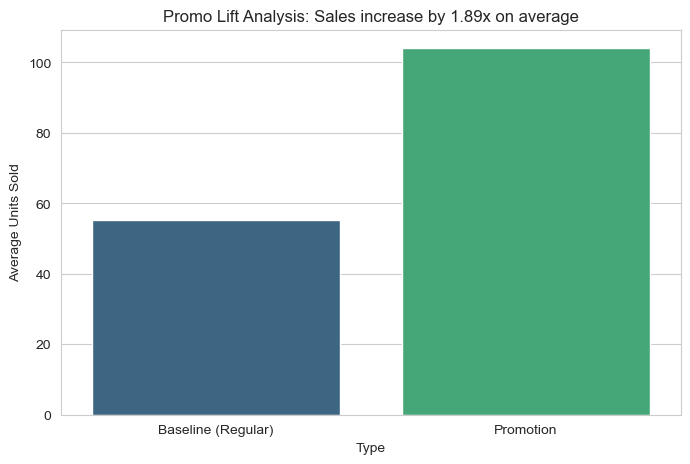

In [2]:
print("\n1. Baseline vs Promotion Performance")

# Compare Average Daily Sales: Baseline (0) vs Promo (1)
promo_stats = df.groupby('promo_flag')['units_sold'].mean().reset_index()
promo_stats['Type'] = promo_stats['promo_flag'].map({0: 'Baseline (Regular)', 1: 'Promotion'})

# Calculate Simple Lift Multiplier
baseline_avg = promo_stats[promo_stats['promo_flag']==0]['units_sold'].values[0]
promo_avg = promo_stats[promo_stats['promo_flag']==1]['units_sold'].values[0]
lift_multiplier = promo_avg / baseline_avg

print(f"Baseline Avg Sales: {baseline_avg:.2f}")
print(f"Promo Avg Sales:    {promo_avg:.2f}")
print(f"Aggregate Lift:     {lift_multiplier:.2f}x")

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(data=promo_stats, x='Type', y='units_sold', palette='viridis')
plt.title(f"Promo Lift Analysis: Sales increase by {lift_multiplier:.2f}x on average")
plt.ylabel("Average Units Sold")
plt.show()

### 2. Promotion Penetration (Over-Promotion Risk)

Requirement: Calculate promo_rate per SKU. Identify items that are "always on sale."


2. Promotion Penetration


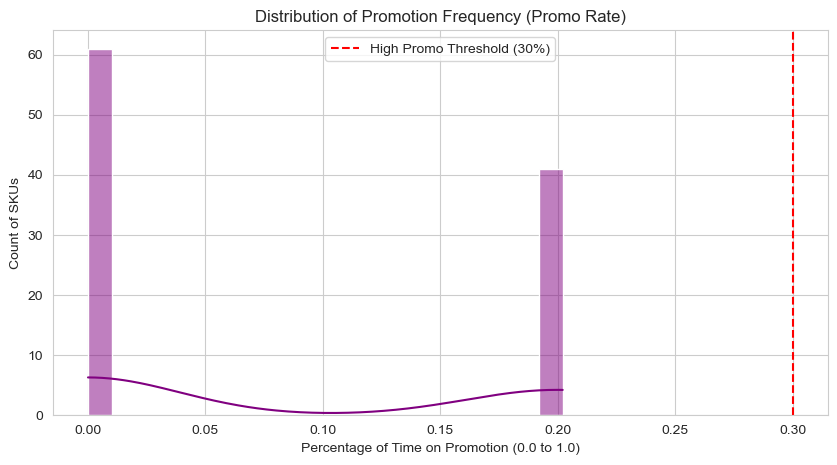

Top 5 Over-Promoted SKUs (Promo Rate > 30%):
Empty DataFrame
Columns: [sku_id, category, promo_rate, units_sold]
Index: []


In [3]:
print("\n2. Promotion Penetration")

# Calculate Promo Frequency per SKU
sku_promo_stats = df.groupby(['sku_id', 'category']).agg({
    'promo_flag': 'mean',          # % of days on promo
    'units_sold': 'sum'            # Total Volume
}).reset_index()

sku_promo_stats.rename(columns={'promo_flag': 'promo_rate'}, inplace=True)

# Visualization: Distribution of Promo Frequency
plt.figure(figsize=(10, 5))
sns.histplot(sku_promo_stats['promo_rate'], bins=20, kde=True, color='purple')
plt.title("Distribution of Promotion Frequency (Promo Rate)")
plt.xlabel("Percentage of Time on Promotion (0.0 to 1.0)")
plt.ylabel("Count of SKUs")
plt.axvline(0.3, color='red', linestyle='--', label='High Promo Threshold (30%)')
plt.legend()
plt.show()

# List "Addicted" SKUs (High Volume + High Promo Rate)
over_promoted = sku_promo_stats[sku_promo_stats['promo_rate'] > 0.3].sort_values('units_sold', ascending=False).head(5)
print("Top 5 Over-Promoted SKUs (Promo Rate > 30%):")
print(over_promoted)

### 3. Price Elasticity Analysis

Requirement: Plot price_index vs units_sold. Do customers respond to discounts?


3. Price Elasticity Analysis


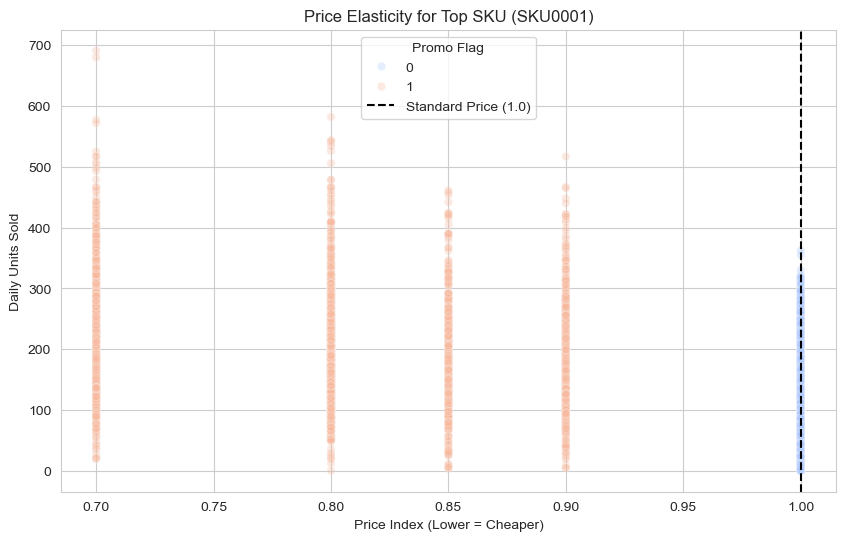

In [4]:
print("\n3. Price Elasticity Analysis")

# We focus on the Top Selling SKU to see a clear curve
top_sku = df.groupby('sku_id')['units_sold'].sum().idxmax()
sku_data = df[df['sku_id'] == top_sku]

plt.figure(figsize=(10, 6))
# Scatter plot with transparency to show density
sns.scatterplot(data=sku_data, x='price_index', y='units_sold', alpha=0.3, hue='promo_flag', palette='coolwarm')

# Reference line for Standard Price
plt.axvline(x=1.0, color='black', linestyle='--', label='Standard Price (1.0)')

plt.title(f"Price Elasticity for Top SKU ({top_sku})")
plt.xlabel("Price Index (Lower = Cheaper)")
plt.ylabel("Daily Units Sold")
plt.legend(title="Promo Flag")
plt.show()

# Insight: If the curve is flat (horizontal), the customer is Price Inelastic (Promotions waste money).
# If the curve goes up to the left (steep), the customer is Price Elastic (Promotions work).

### 4. Inventory Readiness (The "Trap")

Requirement: Check for Stockouts during Promotions.

In [5]:
print("\n4. Inventory Readiness Check")

# Filter for Promotion Days only
promo_days = df[df['promo_flag'] == 1]

# Calculate Stockout Rate DURING promotions
promo_stockout_rate = promo_days['stock_out_flag'].mean()

print(f"Stockout Rate during Promotions: {promo_stockout_rate:.2%}")

if promo_stockout_rate > 0.05:
    print("CRITICAL: More than 5% of promotions result in stockouts. You are burning media money to disappoint customers.")
else:
    print("Inventory levels generally support promotions.")


4. Inventory Readiness Check
Stockout Rate during Promotions: 3.08%
Inventory levels generally support promotions.


## Part 2: Problem Statement 02 – The Supply Chain Disconnect
Reference: docs/eda_supply_chain_disconnect.md

1. Lead Time Variability Analysis
Requirement: Analyze Mean vs. Standard Deviation of lead times.


1. Lead Time Variability


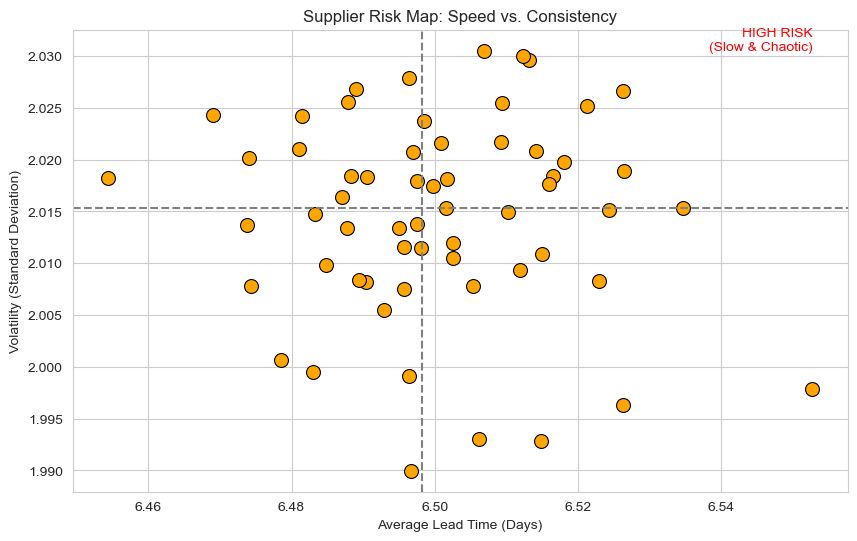

In [6]:
print("\n1. Lead Time Variability")

# Aggregate Lead Time Stats by Supplier
supplier_stats = df.groupby('supplier_id')['lead_time_days'].agg(['mean', 'std']).reset_index()
supplier_stats.columns = ['supplier_id', 'avg_lead_time', 'std_lead_time']

# Visualization: Scatter Plot (The "Risk Map")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=supplier_stats, x='avg_lead_time', y='std_lead_time', s=100, color='orange', edgecolor='black')

plt.title("Supplier Risk Map: Speed vs. Consistency")
plt.xlabel("Average Lead Time (Days)")
plt.ylabel("Volatility (Standard Deviation)")

# Add risk quadrants
plt.axvline(x=supplier_stats['avg_lead_time'].median(), color='grey', linestyle='--')
plt.axhline(y=supplier_stats['std_lead_time'].median(), color='grey', linestyle='--')
plt.text(supplier_stats['avg_lead_time'].max(), supplier_stats['std_lead_time'].max(), "HIGH RISK\n(Slow & Chaotic)", ha='right', color='red')
plt.show()

### 2. Supplier Reliability Assessment (Segmentation)

Requirement: Classify suppliers (Reliable, Unreliable, etc.) using the supplier_cv we engineered.


2. Supplier Reliability Segmentation


/var/folders/_2/v81jjchn4yg2gns8gfgr19rc0000gn/T/ipykernel_32363/2348302626.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=unreliable_suppliers, x='supplier_id', y='supplier_cv', palette='magma')


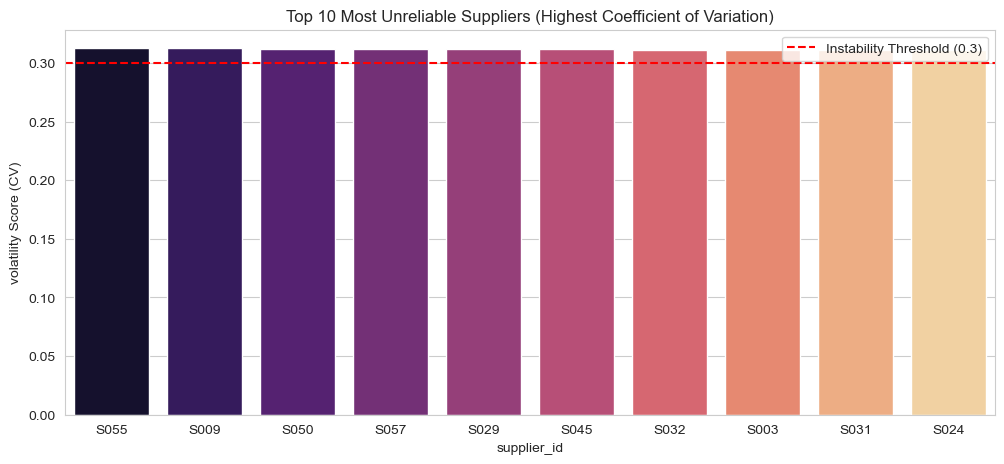

In [7]:
print("\n2. Supplier Reliability Segmentation")

# We use the 'supplier_cv' feature from Notebook 01
# CV > 0.3 is generally considered "Unstable" in supply chain
unreliable_suppliers = df[['supplier_id', 'supplier_cv']].drop_duplicates().sort_values('supplier_cv', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(data=unreliable_suppliers, x='supplier_id', y='supplier_cv', palette='magma')
plt.axhline(0.3, color='red', linestyle='--', label='Instability Threshold (0.3)')
plt.title("Top 10 Most Unreliable Suppliers (Highest Coefficient of Variation)")
plt.ylabel("volatility Score (CV)")
plt.legend()
plt.show()

### 3 & 4. Stockout Root Cause Analysis
Requirement: Analyze Stockouts vs. Lead Time Spikes.


3 & 4. Stockout Root Cause Analysis


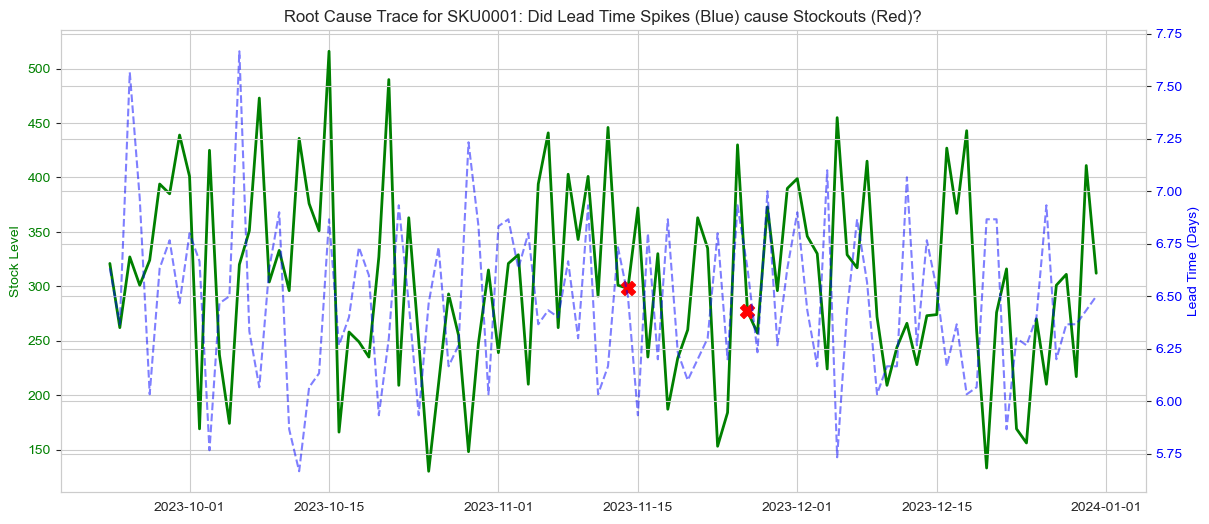

In [8]:
print("\n3 & 4. Stockout Root Cause Analysis")

# We look at the Top SKU again to see the timeline of failure
subset = df[df['sku_id'] == top_sku].tail(100)  # Last 100 days

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot 1: Inventory (Green)
ax1.plot(subset['date'], subset['stock_on_hand'], color='green', label='Stock Level', linewidth=2)
ax1.set_ylabel('Stock Level', color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Plot 2: Lead Times (Blue Dashed) - Shows Supply Stress
ax2 = ax1.twinx()
ax2.plot(subset['date'], subset['lt_rolling_mean_30d'], color='blue', linestyle='--', label='Rolling Lead Time', alpha=0.5)
ax2.set_ylabel('Lead Time (Days)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Highlight Stockouts
stockouts = subset[subset['stock_out_flag'] == 1]
ax1.scatter(stockouts['date'], stockouts['stock_on_hand'], color='red', s=100, marker='X', label='Stockout Event', zorder=5)

plt.title(f"Root Cause Trace for {top_sku}: Did Lead Time Spikes (Blue) cause Stockouts (Red)?")
plt.show()

### 6. Safety Stock Adequacy Check (The "Gap")
Requirement: Compare Existing Buffers vs. required_safety_stock.


6. Safety Stock Adequacy (The Disconnect)
Risk Exposure: 100.0% of SKUs are currently holding LESS safety stock than required by their risk profile.


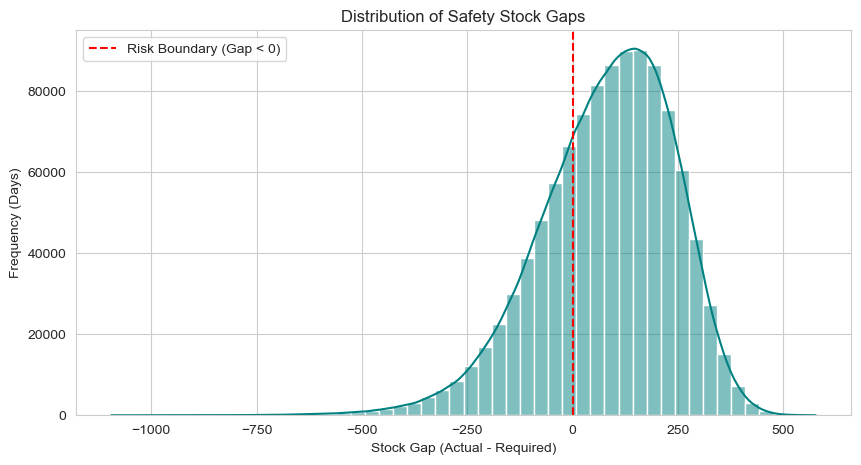

In [9]:
print("\n6. Safety Stock Adequacy (The Disconnect)")

# We analyze the "Gap" feature we engineered
# Gap < 0 means we are Under-Buffered
under_buffered_skus = df[df['under_buffered_flag'] == 1]

risk_count = under_buffered_skus['sku_id'].nunique()
total_skus = df['sku_id'].nunique()
risk_pct = risk_count / total_skus

print(f"Risk Exposure: {risk_pct:.1%} of SKUs are currently holding LESS safety stock than required by their risk profile.")

# Visualization: The "Disconnect" Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['safety_stock_gap'], bins=50, color='teal', kde=True)
plt.axvline(0, color='red', linestyle='--', label='Risk Boundary (Gap < 0)')
plt.title("Distribution of Safety Stock Gaps")
plt.xlabel("Stock Gap (Actual - Required)")
plt.ylabel("Frequency (Days)")
plt.legend()
plt.show()

# Interpretation: The area to the LEFT of the red line represents "The Supply Chain Disconnect."

### 7. Geographic Risk Patterns

Requirement: Analyze Lead Time Variance by Country.


7. Geographic Risk Patterns


/var/folders/_2/v81jjchn4yg2gns8gfgr19rc0000gn/T/ipykernel_32363/2894429265.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_risk, x='country', y='lt_rolling_std_30d', palette='Reds_r')


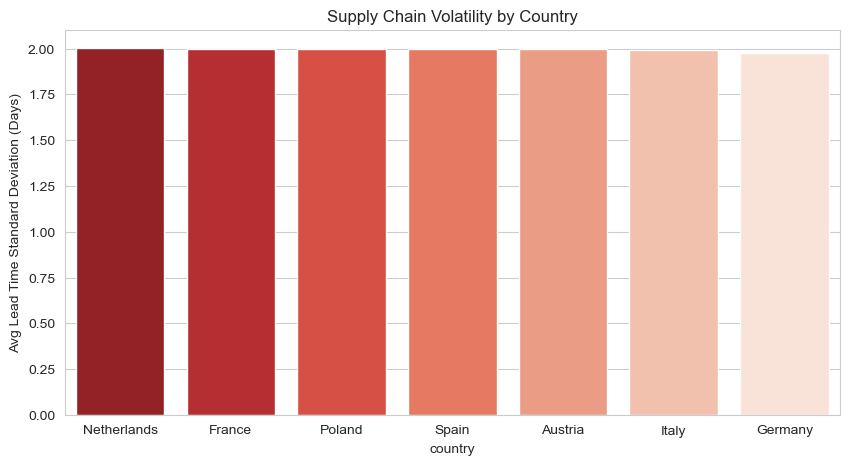

In [10]:
print("\n7. Geographic Risk Patterns")

# Group by Country and calculate average volatility
geo_risk = df.groupby('country')['lt_rolling_std_30d'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=geo_risk, x='country', y='lt_rolling_std_30d', palette='Reds_r')
plt.title("Supply Chain Volatility by Country")
plt.ylabel("Avg Lead Time Standard Deviation (Days)")
plt.show()

### 8.The "True Baseline" Demonstration
Purpose: Show how we distinguish "Organic Demand" from "Promo Spikes"

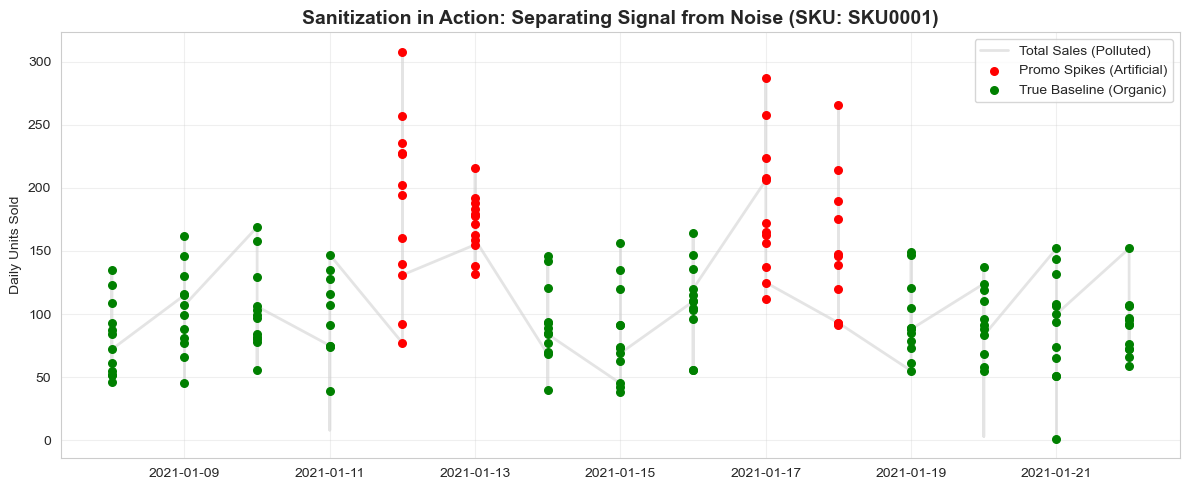

In [11]:
# 1. Select a high-volatility SKU for demonstration (e.g., the one with most promos)
# We find an SKU that has both promos and baseline days
demo_sku = df[df['promo_flag'] == 1]['sku_id'].value_counts().idxmax()
demo_df = df[df['sku_id'] == demo_sku].sort_values('date').iloc[:180] # First 6 months

plt.figure(figsize=(12, 5))

# Plot 1: Total Sales (The "Polluted" Signal)
plt.plot(demo_df['date'], demo_df['units_sold'], 
         color='lightgrey', label='Total Sales (Polluted)', linewidth=2, alpha=0.6)

# Plot 2: Promo Spikes (The "Artificial" Signal)
promo_days = demo_df[demo_df['promo_flag'] == 1]
plt.scatter(promo_days['date'], promo_days['units_sold'], 
            color='red', label='Promo Spikes (Artificial)', zorder=5, s=30)

# Plot 3: True Baseline (The "Organic" Signal)
baseline_days = demo_df[demo_df['is_true_baseline'] == 1]
plt.scatter(baseline_days['date'], baseline_days['units_sold'], 
            color='green', label='True Baseline (Organic)', zorder=5, s=30)

plt.title(f'Sanitization in Action: Separating Signal from Noise (SKU: {demo_sku})', fontsize=14, fontweight='bold')
plt.ylabel('Daily Units Sold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()